# Sentiment Analysis

Train a neural network to classify IMDB movie reviews as **positive** or **negative**. The dataset contains 50,000 reviews (25,000 train / 25,000 test), each pre-encoded as a sequence of word indices ranked by frequency in the corpus.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

MAXLEN = 100      # Truncate/pad all reviews to this many tokens
VOCAB_SIZE = 10000  # Keep only the most frequent words

## Load the IMDB dataset

`keras.datasets.imdb` provides pre-tokenized reviews. `num_words=VOCAB_SIZE` keeps only the top N most frequent words — rarer words are mapped to `<UNK>`. Labels are binary: `1` = positive, `0` = negative.

In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.imdb.load_data(num_words=VOCAB_SIZE)

In [3]:
print("Training samples:", len(x_train))
print("Test samples:", len(x_test))

Training samples: 25000
Test samples: 25000


### Explore the data

The word index maps tokens to integer IDs. Special tokens occupy the first four slots: `<PAD>` (0), `<START>` (1), `<UNK>` (2), `<UNUSED>` (3) — so all real word IDs are shifted by +3. `decode_review` inverts the mapping to reconstruct readable text.

In [4]:
word_index = keras.datasets.imdb.get_word_index()
word_index = {k: (v + 3) for k, v in word_index.items()}
word_index['<PAD>'] = 0
word_index['<START>'] = 1
word_index['<UNK>'] = 2  # Unknown
word_index['<UNUSED>'] = 3  # Unused

def decode_review(encoded_review):
    reverse_word_index = {value: key for key, value in word_index.items()}
    return ' '.join([reverse_word_index.get(i, '<UNK>') for i in encoded_review])

In [5]:
for i in range(2):
    print(f"Review {i + 1}: {decode_review(x_train[i])}")
    print(f"Sentiment: {'Positive' if y_train[i] == 1 else 'Negative'}\n")

Review 1: <START> this film was just brilliant casting location scenery story direction everyone's really suited the part they played and you could just imagine being there robert <UNK> is an amazing actor and now the same being director <UNK> father came from the same scottish island as myself so i loved the fact there was a real connection with this film the witty remarks throughout the film were great it was just brilliant so much that i bought the film as soon as it was released for <UNK> and would recommend it to everyone to watch and the fly fishing was amazing really cried at the end it was so sad and you know what they say if you cry at a film it must have been good and this definitely was also <UNK> to the two little boy's that played the <UNK> of norman and paul they were just brilliant children are often left out of the <UNK> list i think because the stars that play them all grown up are such a big profile for the whole film but these children are amazing and should be prais

## Preprocessing — pad sequences

Reviews have variable lengths but the model needs fixed-size inputs. `pad_sequences` truncates reviews longer than `MAXLEN` tokens and zero-pads shorter ones (prepending `<PAD>` tokens). `MAXLEN=100` captures most of the signal while keeping memory usage low.

In [6]:
x_train_pad = keras.preprocessing.sequence.pad_sequences(x_train, maxlen=MAXLEN)
x_test_pad = keras.preprocessing.sequence.pad_sequences(x_test, maxlen=MAXLEN)

## Build the model

A lightweight but effective architecture for text classification:

- **Embedding**: Learns a dense 64-dimensional vector for each token. Converts integer sequences into continuous representations the network can reason about.
- **GlobalAveragePooling1D**: Averages embeddings across all token positions into a single fixed-size vector — a simple but strong baseline for bag-of-words-style classification.
- **Dense(16, relu)**: Hidden layer for non-linear feature combination.
- **Dropout(0.5)**: Randomly zeroes 50% of activations during training to combat overfitting.
- **Dense(1, sigmoid)**: Outputs a probability — above 0.5 is positive, below is negative.

In [7]:
model = keras.Sequential([
    layers.Embedding(input_dim=VOCAB_SIZE, output_dim=64, input_length=MAXLEN),
    layers.GlobalAveragePooling1D(),
    layers.Dense(16, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model.summary()

/Users/brianbianchi/.pyenv/versions/3.12.9/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ ?                      │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

## Train the model

- `binary_crossentropy`: Standard loss for binary classification — measures the gap between predicted probability and true label.
- `validation_split=0.2`: Holds out 20% of training data to monitor overfitting.
- `EarlyStopping`: Halts training if `val_loss` fails to improve for 2 consecutive epochs and restores the best weights, preventing the model from overfitting past its optimal point.

In [8]:
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=2, restore_best_weights=True)

history = model.fit(
    x_train_pad, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stopping]
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.7482 - loss: 0.5265 - val_accuracy: 0.8332 - val_loss: 0.3716
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8664 - loss: 0.3346 - val_accuracy: 0.8492 - val_loss: 0.3449
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9026 - loss: 0.2700 - val_accuracy: 0.8418 - val_loss: 0.3639
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9213 - loss: 0.2321 - val_accuracy: 0.8386 - val_loss: 0.3706


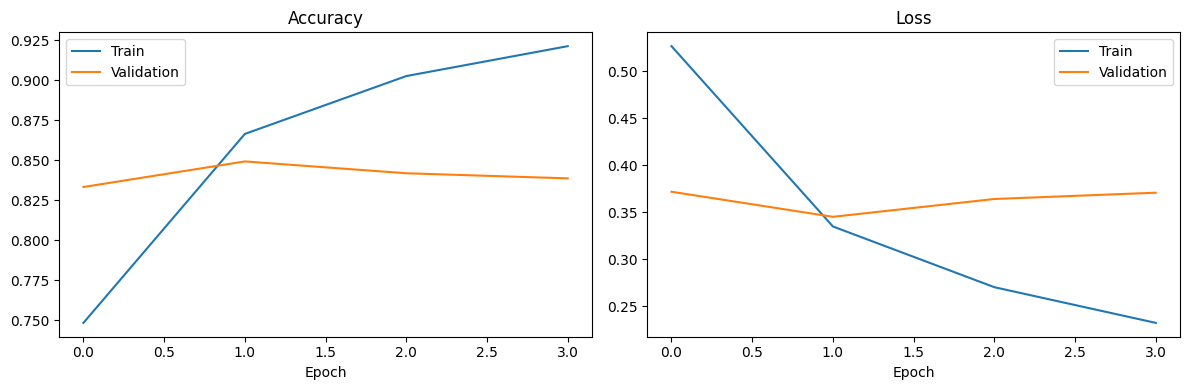

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['accuracy'], label='Train')
axes[0].plot(history.history['val_accuracy'], label='Validation')
axes[0].set_title('Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train')
axes[1].plot(history.history['val_loss'], label='Validation')
axes[1].set_title('Loss')
axes[1].set_xlabel('Epoch')
axes[1].legend()

plt.tight_layout()
plt.show()

In [10]:
test_loss, test_accuracy = model.evaluate(x_test_pad, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 508us/step - accuracy: 0.8464 - loss: 0.3474
Test Loss: 0.3474
Test Accuracy: 0.8464


## Detailed evaluation

Convert output probabilities to binary predictions using a 0.5 threshold. The confusion matrix breaks down true/false positives and negatives; the classification report adds precision, recall, and F1 per class.

In [11]:
y_pred_probs = model.predict(x_test_pad)
y_pred = (y_pred_probs > 0.5).astype(int).flatten()  # Convert probabilities to binary predictions

782/782 ━━━━━━━━━━━━━━━━━━━━ 0s 409us/step


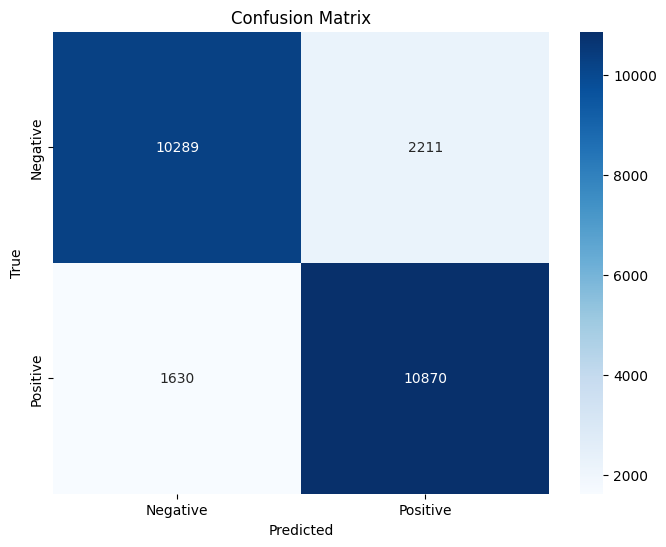

              precision    recall  f1-score   support

           0       0.86      0.82      0.84     12500
           1       0.83      0.87      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



In [12]:
cm = confusion_matrix(y_test, y_pred)
class_report = classification_report(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

print(class_report)

## Save the model

Persist the model architecture and weights in the native Keras format. To reload: `model = keras.models.load_model('models/sentiment_analysis.keras')`.

In [ ]:
model.save('./models/sentiment_analysis.keras')